In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/heart_disease_uci.csv")


In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.shape

(920, 16)

In [6]:
df.columns 

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [9]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) *100

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

id          920
age          50
sex           2
dataset       4
cp            4
trestbps     61
chol        217
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           5
dtype: int64

### Initial Data Quality Assessment 

In [13]:
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [14]:
df["cp"].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [15]:
df["sex"].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

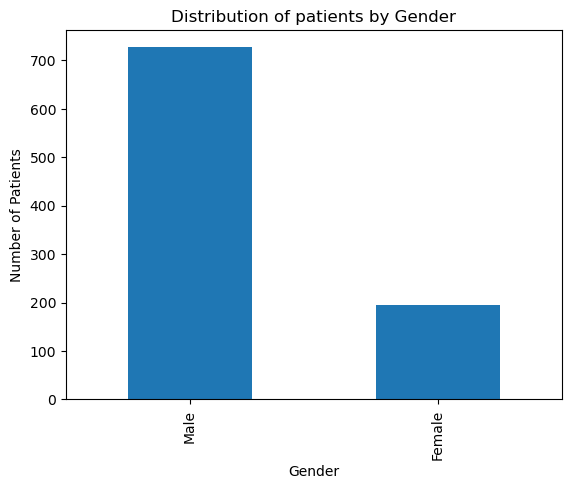

In [16]:
df["sex"].value_counts().plot(kind = "bar")
plt.title("Distribution of patients by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

### Insight
The dataset contains significantly more male patients (726) than female patients (194).This suggests that the dataset is male-dominated,so any conclusions about gender differences should be interpreted carefully, as the sample is not evenly balanced.

## Question 1: Are males more likely than females to have heart disease?

In [17]:
df["heart_disease"] = df ["num"].apply(lambda x: "Yes" if x > 0 else "No")

In [18]:
df["heart_disease"].value_counts()

heart_disease
Yes    509
No     411
Name: count, dtype: int64

In [19]:
pd.crosstab(df["sex"],
            df["heart_disease"])

heart_disease,No,Yes
sex,,
Female,144,50
Male,267,459


In [20]:
pd.crosstab(df["sex"],
            df["heart_disease"],
            normalize = "index") * 100

heart_disease,No,Yes
sex,,
Female,74.226804,25.773196
Male,36.776860,63.223140


Insight Q1: In this dataset approximately 63% of male patients had heart disease compared to about 26% of female patients suggesting a higher prevalence of heart disease among males in this sample.

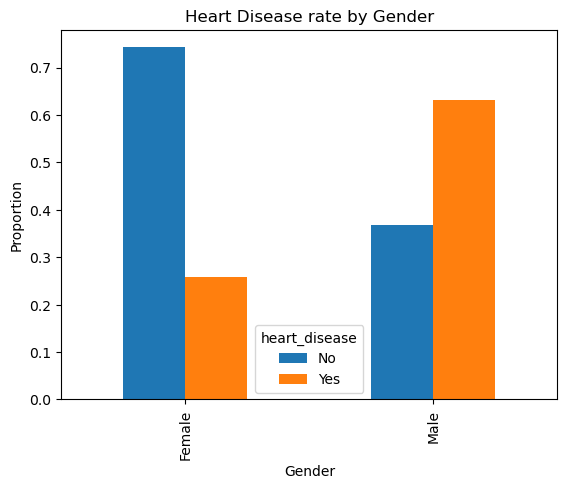

In [21]:
pd.crosstab(df["sex"],
            df["heart_disease"],
            normalize = "index").plot(kind="bar")
plt.title("Heart Disease rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion")
plt.show()

### Queston 2 : Are patients with asymptomatic chest pain more or less likely to have heart disease than patients with typical angina?

In [22]:
pd.crosstab(df["cp"],
            df["heart_disease"],
            normalize = "index") * 100

heart_disease,No,Yes
cp,,
asymptomatic,20.967742,79.032258
atypical angina,86.206897,13.793103
non-anginal,64.215686,35.784314
typical angina,56.521739,43.478261


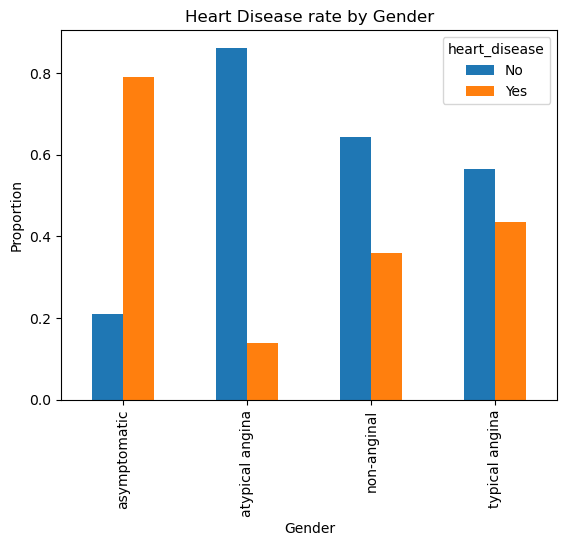

In [23]:
pd.crosstab(df["cp"],
            df["heart_disease"],
            normalize = "index").plot(kind="bar")
plt.title("Heart Disease rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion")
plt.show()

Insght Q2: patients classifed as asymptomatic had the highest proporton of heart disease in this dataset. This suggests that the absence of typical chest pain symptoms does not necessarily indicate the absence of heart disease.

### Question 3: Which dataset has the highest percentage of chest pain and heart disease?

In [24]:
pd.crosstab(df["dataset"],
            df["cp"])

cp,asymptomatic,atypical angina,non-anginal,typical angina
dataset,,,,
Cleveland,144,51,86,23
Hungary,123,105,54,11
Switzerland,98,4,17,4
VA Long Beach,131,14,47,8


In [25]:
pd.crosstab(df["dataset"],
            df["cp"],
            normalize = "index") * 100

cp,asymptomatic,atypical angina,non-anginal,typical angina
dataset,,,,
Cleveland,47.368421,16.776316,28.289474,7.565789
Hungary,41.979522,35.836177,18.430034,3.754266
Switzerland,79.674797,3.252033,13.821138,3.252033
VA Long Beach,65.500000,7.000000,23.500000,4.000000


In [26]:
pd.crosstab(df["dataset"],
            df["heart_disease"])

heart_disease,No,Yes
dataset,,
Cleveland,165,139
Hungary,187,106
Switzerland,8,115
VA Long Beach,51,149


In [27]:
pd.crosstab(df["dataset"],
            df["heart_disease"],
            normalize = "index") * 100

heart_disease,No,Yes
dataset,,
Cleveland,54.276316,45.723684
Hungary,63.822526,36.177474
Switzerland,6.504065,93.495935
VA Long Beach,25.500000,74.500000


Insight Q3: Among patients in this dataset, the Switzerland subset has the highest proportion diagnosed with heart disease (93.5%) and asymptomatic chest pain.

### Question 4: Are older people more likely to have a heart disease?

In [28]:
df["age_group"]= pd.cut(df["age"],
                        bins = [20,39,49,59,69,100],
                        labels=["20-39","40-49","50-59","60-69","70+"])

In [29]:
df["age_group"].value_counts().sort_index()

age_group
20-39     80
40-49    212
50-59    375
60-69    222
70+       31
Name: count, dtype: int64

In [30]:
pd.crosstab(df["age_group"],
            df["heart_disease"],
            normalize = "index") * 100

heart_disease,No,Yes
age_group,,
20-39,67.500000,32.500000
40-49,59.905660,40.094340
50-59,43.200000,56.800000
60-69,26.576577,73.423423
70+,29.032258,70.967742


Insght Q4: Yes, from the dataset, older people are more likely to have a heart disease, because the number of persons with heart disease increases as age increases. 

### Queston 5: Is exercise induced angina associated with heart disease?

In [31]:
pd.crosstab(df["exang"],
            df["heart_disease"])

heart_disease,No,Yes
exang,,
False,336,192
True,55,282


In [32]:
pd.crosstab(df["exang"],
            df["heart_disease"],
            normalize = "index") * 100

heart_disease,No,Yes
exang,,
False,63.636364,36.363636
True,16.320475,83.679525


Insght Q5: Patients with excercise induced angina showed a substaintally higher prevalence of heart disease than those without excercise induced angina (84% vs 36%) .This suggests that excercise induced angina is strongly associated with the presence of heart disease in this dataset.

### Queston 6: Is havng a fasting blood sugar level greater than 120mg/dL associated with heart disease?

In [33]:
pd.crosstab(df["fbs"],
            df["heart_disease"])

heart_disease,No,Yes
fbs,,
False,353,339
True,44,94


In [34]:
pd.crosstab(df["fbs"],
            df["heart_disease"],
            normalize = "index") * 100

heart_disease,No,Yes
fbs,,
False,51.011561,48.988439
True,31.884058,68.115942


Insght Q6: Patients with high fasting blood sugar had a high prevalence of heart disease than those with normal fasting sugar (68% vs 49%) .This suggests a moderate association between fasting blood sugar and heart disease in this dataset.

### Question 7: What is the associaton between resting ECG and heart disease?

In [35]:
pd.crosstab(df["restecg"],
            df["heart_disease"])

heart_disease,No,Yes
restecg,,
lv hypertrophy,82,106
normal,268,283
st-t abnormality,61,118


In [36]:
pd.crosstab(df["restecg"],
            df["heart_disease"],
            normalize = "index") * 100

heart_disease,No,Yes
restecg,,
lv hypertrophy,43.617021,56.382979
normal,48.638838,51.361162
st-t abnormality,34.078212,65.921788


Insight Q7: Heart disease prevalence varied across restng ECG categories, ranging from 51% among patients with normal ECG results to 66% among those with ST-T wave abnormalites. While normal ECG findings were associated with a higher prevalence of heart disease, the differences between groups are relatively modest compared with other predictors, suggesting that resting ECG alone is a weak to moderate indcator of heart disease in this dataset.

### Question 8: How does the distribution of cholesterol differ between patients with and without heart disease?

In [37]:
df.groupby("heart_disease")["chol"].describe()

,count,mean,std,min,25%,50%,75%,max
heart_disease,,,,,,,,
No,392.0,227.905612,75.832760,0.0,199.0,228.0,269.00,564.0
Yes,498.0,176.479920,127.517611,0.0,0.0,218.0,267.75,603.0


<Figure size 800x500 with 0 Axes>

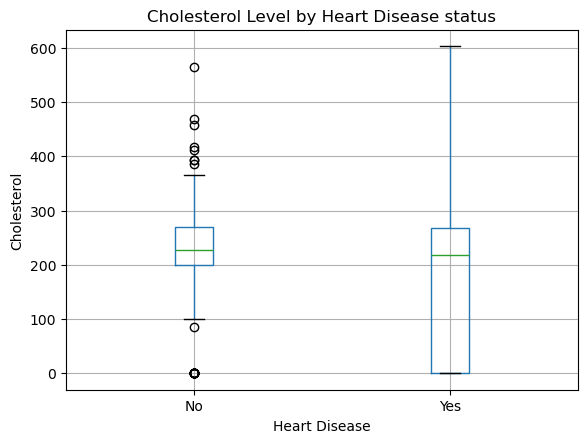

In [38]:
plt.figure(figsize=(8,5))
df.boxplot(column = "chol", by="heart_disease")
plt.title("Cholesterol Level by Heart Disease status")
plt.suptitle("") #Removes the automatic title added by pandas
plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.show()

Insight Q9: In this dataset, patients without heart disease had slightly higher average and median cholesterol levels than patients with heart disease. This finding differs from what might be expected clinically and suggests that cholesterol alone is not a strong discriminator of heart disease in this dataset.

### Q9. Do patients with heart disease generally have higher resting blood pressure than those without heart disease?

In [39]:
df.groupby("heart_disease")["trestbps"].describe()

,count,mean,std,min,25%,50%,75%,max
heart_disease,,,,,,,,
No,391.0,129.913043,16.869867,80.0,120.0,130.0,140.0,190.0
Yes,470.0,133.978723,20.552278,0.0,120.0,130.0,145.0,200.0


<Figure size 800x500 with 0 Axes>

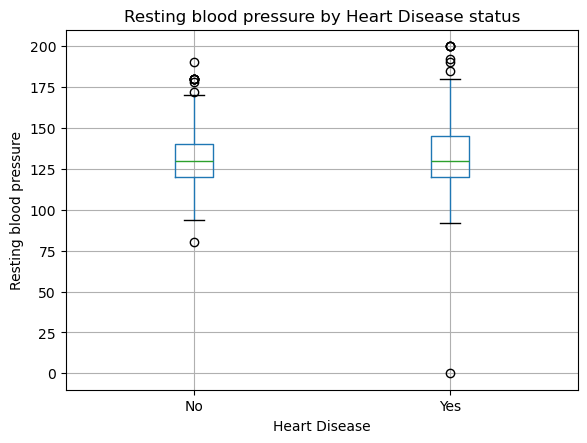

In [40]:
plt.figure(figsize=(8,5))
df.boxplot(column = "trestbps", by="heart_disease")
plt.title("Resting blood pressure by Heart Disease status")
plt.suptitle("") #Removes the automatic title added by pandas
plt.xlabel("Heart Disease")
plt.ylabel("Resting blood pressure")
plt.show()

Insght Q9: Patients with higher resting blood pressure had a high prevalence of heart disease than those with normal resting blood pressure.This suggests a moderate association between resting blood pressure and heart disease in this dataset.

### Q10. Do patients with heart disease generally have higher maximum heart rate than those without heart disease?

In [41]:
df.groupby("heart_disease")["thalch"].describe()

,count,mean,std,min,25%,50%,75%,max
heart_disease,,,,,,,,
No,391.0,148.800512,23.608692,69.0,134.5,151.0,167.5,202.0
Yes,474.0,128.261603,24.024193,60.0,112.0,128.0,145.0,195.0


<Figure size 800x500 with 0 Axes>

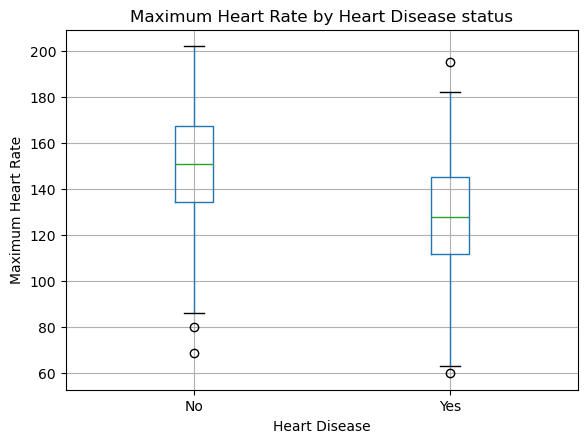

In [42]:
plt.figure(figsize=(8,5))
df.boxplot(column = "thalch", by="heart_disease")
plt.title("Maximum Heart Rate by Heart Disease status")
plt.suptitle("") #Removes the automatic title added by pandas
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.show()

Insight Q10: patients with heart disease had substantially lower maximum heart rates than those without heart disease (128.3 vs 148.8 bpm). The median values showed a similar pattern (128 vs 151 bpm), while variabilty is comparable between groups. This suggests that maximum heart rate is an important variable associated with heart disease in this dataset.

### Which numerical values are correlated?

In [43]:
corr = df.corr(numeric_only = True)
corr

,id,age,trestbps,chol,thalch,oldpeak,ca,num
id,1.000000,0.239301,0.052924,-0.376936,-0.466427,0.049930,0.061433,0.273552
age,0.239301,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.339596
trestbps,0.052924,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.122291
chol,-0.376936,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.231547
thalch,-0.466427,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.366265
oldpeak,0.049930,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.443084
ca,0.061433,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.516216
num,0.273552,0.339596,0.122291,-0.231547,-0.366265,0.443084,0.516216,1.000000


 +1 shows positive relationship, 0 shows no relationship, -1 shows negative relationship

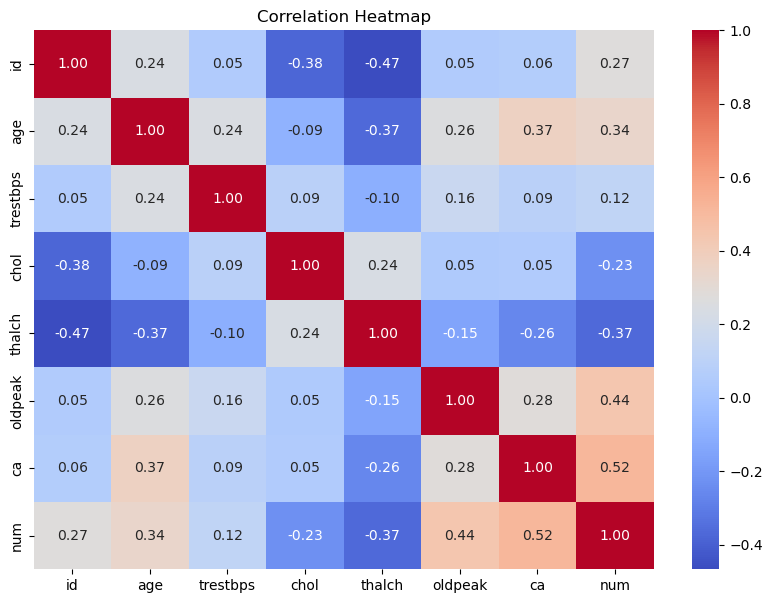

In [44]:
#Heatmap to show correlation 
import seaborn as sns
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Insight: Ca and num have the strongest postive relatonship, meaning as ca is increasing num (heart rate) is increasing. Thalch and num have the strongest negative relationship meaning as Thalch (maximum heart rate) is increasing num(heart rate)is decreasing and vice versa. 

In [45]:
# Because id in the dataset is not a variable but an identifer for each patient, and num is the original disease severity variable, we can remove them and revisualize the heatmap:
corr_data = df.select_dtypes(include="number").drop(columns=["id","num"])
corr = corr_data.corr()

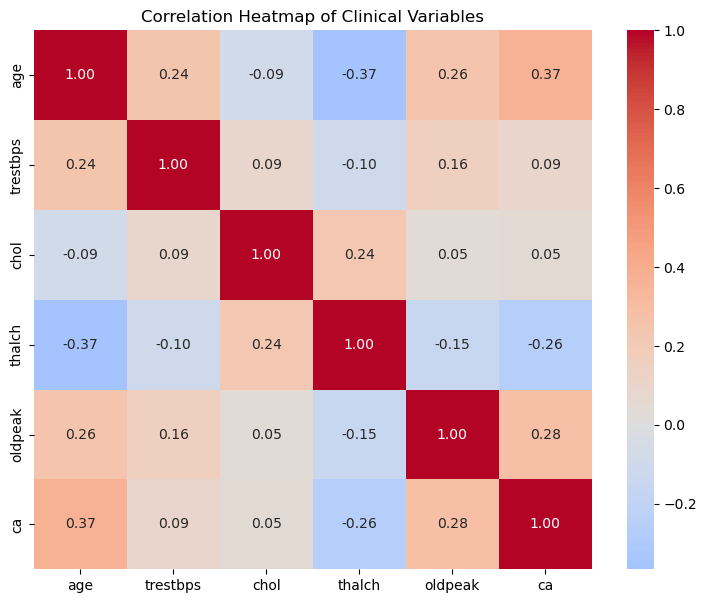

In [46]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap of Clinical Variables")
plt.show()

### Outlier detection

To detect any outliers, we use the interquartile range (IQR) method, where IQR=Q3-Q1 
where Q1=25th percentle, Q3=75th percentile
lower Boundary=Q1-1.5(IQR)
Upper Boundary=Q3+1.5(IQR)

In [47]:
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))


age
Q1: 47.0
Q3: 60.0
IQR: 13.0
Lower bound: 27.5
Upper bound: 79.5
Number of outliers: 0

trestbps
Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 28

chol
Q1: 175.0
Q3: 268.0
IQR: 93.0
Lower bound: 35.5
Upper bound: 407.5
Number of outliers: 183

thalch
Q1: 120.0
Q3: 157.0
IQR: 37.0
Lower bound: 64.5
Upper bound: 212.5
Number of outliers: 2

oldpeak
Q1: 0.0
Q3: 1.5
IQR: 1.5
Lower bound: -2.25
Upper bound: 3.75
Number of outliers: 16

ca
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower bound: -1.5
Upper bound: 2.5
Number of outliers: 20


In [48]:
#To organize this results in a dataframe, first we create an empty list
outlier_results = []

#second we modify the loop to add the results to the list
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

outlier_results = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_results.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

#Third we convert the list to a dataframe
outlier_df = pd.DataFrame(outlier_results)

outlier_df

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age,47.0,60.0,13.0,27.50,79.50,0
1,trestbps,120.0,140.0,20.0,90.00,170.00,28
2,chol,175.0,268.0,93.0,35.50,407.50,183
3,thalch,120.0,157.0,37.0,64.50,212.50,2
4,oldpeak,0.0,1.5,1.5,-2.25,3.75,16
5,ca,0.0,1.0,1.0,-1.50,2.50,20


In [49]:
#cholesterol values have the highest potential outliers, let's check for what the extreme values are
df["chol"].describe()

count    890.000000
mean     199.130337
std      110.780810
min        0.000000
25%      175.000000
50%      223.000000
75%      268.000000
max      603.000000
Name: chol, dtype: float64

In [50]:
df["chol"].sort_values(ascending=False).head(10)

546    603.0
152    564.0
528    529.0
568    518.0
584    491.0
434    468.0
500    466.0
800    458.0
48     417.0
373    412.0
Name: chol, dtype: float64

The min cholesterol level is 0 which is unsual for someone to have so we investigate if 0 a genuine cholesterol measurement, or is it being used to represent a missing/unknown value?

In [51]:
(df["chol"] == 0).sum()

np.int64(172)

172 rows have a cholesterol of 0

In [52]:
# To check for the actual rows having chol of 0
df[df["chol"] == 0]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,heart_disease,age_group
597,598,32,Male,Switzerland,typical angina,95.0,0.0,NaN,normal,127.0,False,0.7,upsloping,NaN,NaN,1,Yes,20-39
598,599,34,Male,Switzerland,asymptomatic,115.0,0.0,NaN,NaN,154.0,False,0.2,upsloping,NaN,NaN,1,Yes,20-39
599,600,35,Male,Switzerland,asymptomatic,NaN,0.0,NaN,normal,130.0,True,NaN,NaN,NaN,reversable defect,3,Yes,20-39
600,601,36,Male,Switzerland,asymptomatic,110.0,0.0,NaN,normal,125.0,True,1.0,flat,NaN,fixed defect,1,Yes,20-39
601,602,38,Female,Switzerland,asymptomatic,105.0,0.0,NaN,normal,166.0,False,2.8,upsloping,NaN,NaN,2,Yes,20-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,819,43,Male,VA Long Beach,asymptomatic,122.0,0.0,False,normal,120.0,False,0.5,upsloping,NaN,NaN,1,Yes,40-49
819,820,63,Male,VA Long Beach,non-anginal,130.0,0.0,True,st-t abnormality,160.0,False,3.0,flat,NaN,NaN,0,No,60-69
822,823,48,Male,VA Long Beach,non-anginal,102.0,0.0,NaN,st-t abnormality,110.0,True,1.0,downsloping,NaN,NaN,1,Yes,40-49
839,840,56,Male,VA Long Beach,asymptomatic,NaN,0.0,False,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,1,Yes,50-59


172 records have a cholesterol value of 0, and the concentration of these zeros in a consecutive section of the dataset (597-840) strongly suggests a data-entry or missing-value issue.

To check whether other variables also suddenly become 0 in that same section. If we find that several variables have suspicious zeros in the same rows, that's a strong evidence that something happened to that section of the dataset.

In [53]:
df.loc[597:840].isna().sum()

id                 0
age                0
sex                0
dataset            0
cp                 0
trestbps          33
chol               1
fbs               82
restecg            1
thalch            30
exang             30
oldpeak           37
slope             71
ca               237
thal             154
num                0
heart_disease      0
age_group          0
dtype: int64

In [54]:
df.loc[597:840, ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]].eq(0).sum()

age           0
trestbps      1
chol        172
thalch        0
oldpeak      63
ca            2
dtype: int64

In [55]:
chol_zero_rows = df.index[df["chol"] == 0]

chol_zero_rows

Index([597, 598, 599, 600, 601, 602, 603, 604, 605, 606,
       ...
       785, 787, 788, 796, 812, 818, 819, 822, 839, 840],
      dtype='int64', length=172)

In [56]:
chol_zero_rows.min(), chol_zero_rows.max()

(np.int64(597), np.int64(840))

In [57]:
df.loc[chol_zero_rows, [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca",
    "thal",
    "heart_disease"
]].isna().sum()

age                0
trestbps          13
chol               0
thalch            10
oldpeak           15
ca               166
thal              91
heart_disease      0
dtype: int64

Observation: 172 observations have cholesterol recorded as 0, and these observations are concentrated between rows 597 and 840, although the zero values are not present in every row in that range. ca and thal also have a high number of missing values within that range.

### Data Cleaning 

In [58]:
#create a copy of the dataset
df_clean =df.copy()

In [59]:
df_clean["chol"] =df_clean["chol"].replace(0,np.nan)

In [60]:
#calculate the number of missing values
df_clean.isna().sum()

id                 0
age                0
sex                0
dataset            0
cp                 0
trestbps          59
chol             202
fbs               90
restecg            2
thalch            55
exang             55
oldpeak           62
slope            309
ca               611
thal             486
num                0
heart_disease      0
age_group          0
dtype: int64

In [61]:
# To calculate the percentage of missing values 
missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isna().sum(),
    "Missing Percentage": (df_clean.isna().sum() / len(df_clean)) * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
ca,611,66.413043
thal,486,52.826087
slope,309,33.586957
chol,202,21.956522
fbs,90,9.782609
oldpeak,62,6.739130
trestbps,59,6.413043
thalch,55,5.978261
exang,55,5.978261
restecg,2,0.217391


Missing-value assessment: ca, thal, and slope contain substantial missing data, with ca having the highest missingness (66.4%). These are too heavily missing for us to casually replace them with averages or modes. So we keep their missing values as NaN and not fabricate values that weren't recorded.

In [62]:
#Among patients without heart disease and patients with heart disease, how many have missing ca, thal, and slope values?
df_clean.groupby("heart_disease")[["ca", "thal", "slope"]].apply(
    lambda x: x.isna().sum()
)

,ca,thal,slope
heart_disease,,,
No,246,224,193
Yes,365,262,116


In [63]:
df_clean["heart_disease"].value_counts()

heart_disease
Yes    509
No     411
Name: count, dtype: int64

| Variable | Without heart disease (411) | With heart disease (509) |
| -------- | --------------------------: | -----------------------: |
| `ca`     |                       59.9% |                    71.7% |
| `thal`   |                       54.5% |                    51.5% |
| `slope`  |                       47.0% |                    22.8% |


Missing values occur across both heart-disease groups, although the proportion varies by variable. 

In [64]:
#find out the distribution of ca values includng NaN values
df_clean["ca"].value_counts(dropna=False).sort_index()

ca
0.0    181
1.0     67
2.0     41
3.0     20
NaN    611
Name: count, dtype: int64

To find out where the missing values are coming from, Different portions of the original data may have been collected from different sources, and the missingness could be concentrated in one source.

In [65]:
#To find out where the missing values are coming from, as different portions of the original data was collected from different sources, and the missingness could be concentrated in one source.
df_clean.groupby("dataset")[["ca", "thal", "slope"]].apply(
    lambda x: x.isna().sum()
)

,ca,thal,slope
dataset,,,
Cleveland,5,3,1
Hungary,290,265,189
Switzerland,118,52,17
VA Long Beach,198,166,102


The missing values are heavily concentrated in Hungary, Switzerland and VA Long Beach, rather than being randomly scattered across the entire dataset.

In [69]:
#For the smaller missing numerical variables, we'll use the median because it's less affected by extreme values than the mean.
# Fill numerical missing values with their median
for col in ["trestbps", "thalch", "oldpeak"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [71]:
# Fill categorical missing values with the mode
for col in ["fbs", "exang", "restecg"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [72]:
df_clean.isna().sum()

id                 0
age                0
sex                0
dataset            0
cp                 0
trestbps           0
chol             202
fbs                0
restecg            0
thalch             0
exang              0
oldpeak            0
slope            309
ca               611
thal             486
num                0
heart_disease      0
age_group          0
dtype: int64

we have successfully filled the missing values for the smaller missing numerical variables

In [73]:
#check for duplicate rows
df_clean.duplicated().sum()

np.int64(0)

In [74]:
#check the final dataset size
df_clean.shape

(920, 18)

In [75]:
df_clean.isna().sum()

id                 0
age                0
sex                0
dataset            0
cp                 0
trestbps           0
chol             202
fbs                0
restecg            0
thalch             0
exang              0
oldpeak            0
slope            309
ca               611
thal             486
num                0
heart_disease      0
age_group          0
dtype: int64

In [76]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   id             920 non-null    int64   
 1   age            920 non-null    int64   
 2   sex            920 non-null    object  
 3   dataset        920 non-null    object  
 4   cp             920 non-null    object  
 5   trestbps       920 non-null    float64 
 6   chol           718 non-null    float64 
 7   fbs            920 non-null    bool    
 8   restecg        920 non-null    object  
 9   thalch         920 non-null    float64 
 10  exang          920 non-null    bool    
 11  oldpeak        920 non-null    float64 
 12  slope          611 non-null    object  
 13  ca             309 non-null    float64 
 14  thal           434 non-null    object  
 15  num            920 non-null    int64   
 16  heart_disease  920 non-null    object  
 17  age_group      920 non-null    cate

In [77]:
df_clean.to_csv("../data/heart_disease_clean.csv", index=False)